# Extract LFPs from our own data
## Understanding filtering artifacts and chunking when extracting LFPs
Local Field Potentials (LFPs) are low-frequency signals (<300 Hz) that reflect the summed activity of many neurons. Extracting LFPs from high-sampling-rate recordings requires bandpass filtering, but this can introduce artifacts when not done carefully, especially when data is processed in chunks (which is usually the required because datasets cannot be loaded entirely into memory).

Before we get started, let’s introduce some important concepts:

### Chunk
A “chunk” is a piece of recording that gets processed in parallel by SpikeInterface. The default chunk duration for most operations is 1 second, but we’ll see how this is not adequate for LFP processing.

### Margin
When we apply a filter on chunked data, we extract additional “margins” of traces at the chunk borders. This is done to reduce border artifacts.

This tutorial demonstrates:

1. How to generate simulated LFP data
2. Common pitfalls when filtering with low cutoff frequencies
3. How chunking and margins affect filtering artifacts
4. Summary

**Key takeaway**: For LFP extraction, use large chunks (30-60s) and large margins (several seconds) to minimize edge artifacts, even though this is less memory-efficient.

## Import necessary libraries

In [1]:
import time
import numpy as np
# %matplotlib widget
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.widgets as sw

## 1. Read our wideband recordings

In [3]:
# Data paths
# SP1
sp1_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_1_20171017/spike_sorting_Thresh_9_9/Data/")
# SP6
sp6_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_6_20180628/spike_sorting_Thresh_9_9/Data/")
# SP7
sp7_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_7_20190305/spike_sorting_Thresh_9_9/Data/")
# SP9
sp9_path = Path("/Volumes/AFedor_T7/TTK-NeuroData/sp_9_20220215/spike_sorting_Thresh_9_9/Data/")

### Read the recording data

In [4]:
# Create dictionaries to store data for each subject
sp1 = dict()
sp6 = dict()
sp7 = dict()
sp9 = dict()

# Load data for each recording
# SP1
sp1['01'] = si.core.read_binary(sp1_path / "01/01.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp1['02'] = si.core.read_binary(sp1_path / "02/02.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp1['03'] = si.core.read_binary(sp1_path / "03/03.dat", sampling_frequency=20000, num_channels=32, dtype='int16')

# SP6
sp6['01'] = si.core.read_binary(sp6_path / "01/01.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp6['02'] = si.core.read_binary(sp6_path / "02/02.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp6['03'] = si.core.read_binary(sp6_path / "03/03.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp6['04'] = si.core.read_binary(sp6_path / "04/04.dat", sampling_frequency=20000, num_channels=32, dtype='int16')

# SP7
sp7['01'] = si.core.read_binary(sp7_path / "01/01.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp7['02'] = si.core.read_binary(sp7_path / "02/02.dat", sampling_frequency=20000, num_channels=32, dtype='int16')

# SP9
sp9['01'] = si.core.read_binary(sp9_path / "01/01.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp9['02'] = si.core.read_binary(sp9_path / "02/02.dat", sampling_frequency=20000, num_channels=32, dtype='int16')
sp9['03'] = si.core.read_binary(sp9_path / "03/03.dat", sampling_frequency=20000, num_channels=32, dtype='int16')

### Create the recording objects containing the wideband signal which includes spikes and LFP as well

In [31]:
# Let's automate for all recordings in SP1, SP6, SP7, and SP9.
# Create a function to load recordings from a given path
def load_recordings(session_id, recording_id, session_name):
    recording_name = str(session_name) + '_' + str(recording_id)
    print(f"Loading recording: {recording_name}")
    recordings[recording_name] = session_id[recording_id]
    return recordings[recording_name]

In [32]:
# Let's use the function to load recordings for SP1, SP6, SP7, and SP9
recordings = dict()
sessions = [sp1, sp6, sp7, sp9]
session_names = ['sp1', 'sp6', 'sp7', 'sp9']  # Adjust based on the number of recordings in each session
for session, session_name in zip(sessions, session_names):
    for recording_id in session.keys():
        load_recordings(session, recording_id, session_name)

print("\n")
print(recordings.keys())
print(recordings['sp1_01'].dtype)

Loading recording: sp1_01
Loading recording: sp1_02
Loading recording: sp1_03
Loading recording: sp6_01
Loading recording: sp6_02
Loading recording: sp6_03
Loading recording: sp6_04
Loading recording: sp7_01
Loading recording: sp7_02
Loading recording: sp9_01
Loading recording: sp9_02
Loading recording: sp9_03


dict_keys(['sp1_01', 'sp1_02', 'sp1_03', 'sp6_01', 'sp6_02', 'sp6_03', 'sp6_04', 'sp7_01', 'sp7_02', 'sp9_01', 'sp9_02', 'sp9_03'])
int16


### Visualize a short segment of the signal

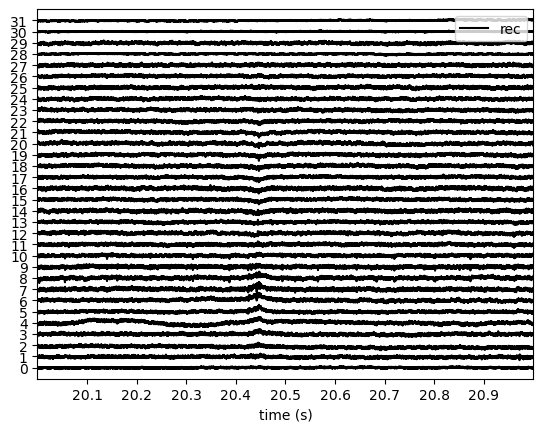

In [40]:
# Quickly visualize one of the recordings to check if the data is loaded correctly
_ = sw.plot_traces(recordings['sp9_01'], time_range=[20, 21], show_channel_ids=True)

## 2. Filtering with low cutoff frequencies

In [36]:
recordings_filt = dict()

for recording_name, recording in recordings.items():
    print(f"Filtering recording: {recording_name}")
    recordings_filt[recording_name] = spre.bandpass_filter(
        recording, freq_min=1.0, freq_max=300.0, ignore_low_freq_error=True)
print("\n")
print("Recordings filtered successfully")

Filtering recording: sp1_01
Filtering recording: sp1_02
Filtering recording: sp1_03
Filtering recording: sp6_01
Filtering recording: sp6_02
Filtering recording: sp6_03
Filtering recording: sp6_04
Filtering recording: sp7_01
Filtering recording: sp7_02
Filtering recording: sp9_01
Filtering recording: sp9_02
Filtering recording: sp9_03


Recordings filtered successfully


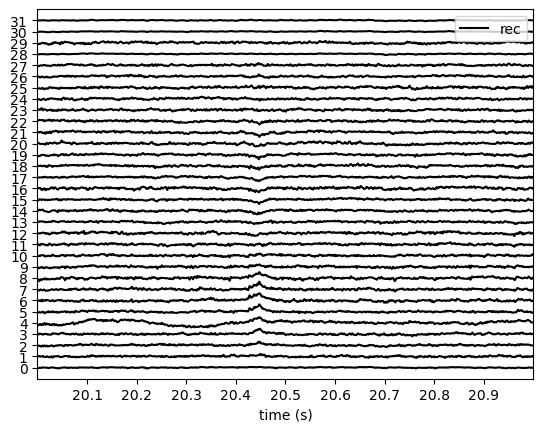

In [41]:
# Quickly visualize one of the filtered recordings to check if the data is filtered correctly
_ = sw.plot_traces(recordings_filt['sp9_01'], time_range=[20, 21], show_channel_ids=True)

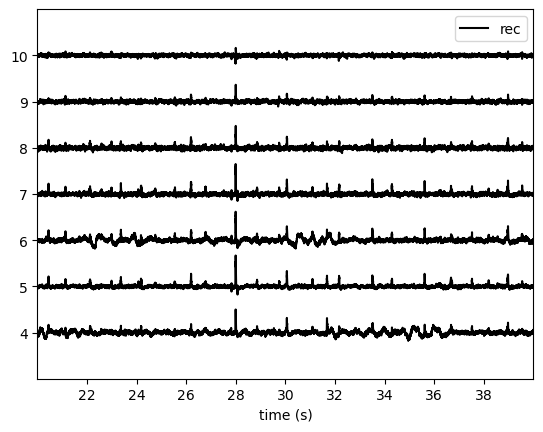

In [44]:
# Let's visualize a longer segment of a few channels of the filtered recording to check the quality of the LFP signal
_ = sw.plot_traces(recordings_filt['sp9_01'], time_range=[20, 40], show_channel_ids=True, channel_ids=[4, 5, 6, 7, 8, 9, 10])

## 3. Saving all of the recordings as one big chunk for each
This can be done because our recordings are not that huge.

Previous analysis showed that there is not a significant time difference between chunking and saving as one.

But this way we have zero border artifacts.

The best we can do is to save the full recording in one chunk. This will cause no artifacts and chunking effects, but in practice it’s not possible due to the duration and number of channels of most setups.

In [ ]:
# Saving the filtered recordings to disk for later use
for recording_name, recording_filt in recordings_filt.items():
    t_start_optimal = time.perf_counter()
    recording_filt.save(
        folder=f"./cached/own_data/{recording_name}/optimal",
        chunk_duration="300s",
        n_jobs=4,
        progress_bar=True,
        overwrite=True
    )
    t_end_optimal = time.perf_counter()
    print(f"Saved filtered recording {recording_name} in {t_end_optimal - t_start_optimal:.2f} seconds")

write_binary 
engine=process - n_jobs=4 - samples_per_chunk=6,000,000 - chunk_memory=366.21 MiB - total_memory=1.43 GiB - chunk_duration=300.00s (5.00 minutes)


write_binary (workers: 1 processes spawn):   0%|          | 0/1 [00:00<?, ?it/s]

Saved filtered recording sp1_01 in 6.51 seconds
write_binary 
engine=process - n_jobs=4 - samples_per_chunk=6,000,000 - chunk_memory=366.21 MiB - total_memory=1.43 GiB - chunk_duration=300.00s (5.00 minutes)


write_binary (workers: 1 processes spawn):   0%|          | 0/1 [00:00<?, ?it/s]

Saved filtered recording sp1_02 in 4.88 seconds
write_binary 
engine=process - n_jobs=4 - samples_per_chunk=6,000,000 - chunk_memory=366.21 MiB - total_memory=1.43 GiB - chunk_duration=300.00s (5.00 minutes)


...

Saved filtered recording sp9_01 in 4.89 seconds
write_binary 
engine=process - n_jobs=4 - samples_per_chunk=6,000,000 - chunk_memory=366.21 MiB - total_memory=1.43 GiB - chunk_duration=300.00s (5.00 minutes)


write_binary (workers: 1 processes spawn):   0%|          | 0/1 [00:00<?, ?it/s]

Saved filtered recording sp9_02 in 4.86 seconds
write_binary 
engine=process - n_jobs=4 - samples_per_chunk=6,000,000 - chunk_memory=366.21 MiB - total_memory=1.43 GiB - chunk_duration=300.00s (5.00 minutes)


write_binary (workers: 1 processes spawn):   0%|          | 0/1 [00:00<?, ?it/s]

Saved filtered recording sp9_03 in 4.76 seconds


Now any filtered LFP recording can be loaded from the disk for further analysis and later use